# Data Cleaning

In [1]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [2]:
print("Loading processed datasets...")

# Load raw processed data (before analytics stage transformations)
df_processed_tracks = pd.read_parquet(config.PROCESSED_TRACKS)
df_processed_artists = pd.read_parquet(config.PROCESSED_ARTISTS)
df_processed_albums = pd.read_parquet(config.PROCESSED_ALBUMS)
df_processed_features = pd.read_parquet(config.PROCESSED_TRACK_FEATURES)

print(f"Processed Tracks loaded:   {len(df_processed_tracks):,}")
print(f"Processed Artists loaded:  {len(df_processed_artists):,}")
print(f"Processed Albums loaded:   {len(df_processed_albums):,}")
print(f"Processed Features loaded: {len(df_processed_features):,}")


Loading processed datasets...
Processed Tracks loaded:   101,939
Processed Artists loaded:  56,129
Processed Albums loaded:   75,511
Processed Features loaded: 101,909


## Analytics Stage Transformations

Building business-ready tables: denormalization, column selection, and type casting.


In [3]:
# Build Analytics Artists Table
print("Building analytics artists table...")

df_artists = df_processed_artists[[
    "artist_id", "artist_name", "artist_popularity", "followers", "type",
    "genres"
]].copy()

# Ensure correct types
df_artists["artist_popularity"] = df_artists["artist_popularity"].fillna(0).astype("int64")
df_artists["followers"] = df_artists["followers"].fillna(0).astype("int64")

print(f"Analytics artists: {len(df_artists):,} rows")


Building analytics artists table...
Analytics artists: 56,129 rows


In [4]:
# Build Analytics Albums Table (with artist denormalization)
print("Building analytics albums table...")

# FILTER: Only keep albums that reference an existing artist (Foreign Key constraint)
valid_artist_ids = df_artists["artist_id"].unique()
df_albums = df_processed_albums[df_processed_albums["artist_id"].isin(valid_artist_ids)].copy()

print(f"Filtered albums: {len(df_albums):,}/{len(df_processed_albums):,} reference valid artists")

# Prepare artist columns with prefix to avoid conflicts
artists_cols = df_artists.copy()
artists_cols = artists_cols.rename(
    columns={c: f"artist_{c}" for c in df_artists.columns}
)

# Join albums with artists
df_albums = df_albums.merge(
    artists_cols,
    left_on="artist_id",
    right_on="artist_artist_id",
    how="left",
)

# Select and rename final columns
df_albums = df_albums[[
    "album_id", "album_name", "album_type", "release_date", "total_tracks",
    "uri", "artist_id", "artist_artist_name", "artist_followers",
    "artist_artist_popularity"
]].copy()

df_albums = df_albums.rename(
    columns={
        "artist_artist_name": "artist_name",
        "artist_artist_popularity": "artist_popularity",
    }
)

# Ensure correct types for database sync
df_albums["total_tracks"] = df_albums["total_tracks"].fillna(0).astype("int64")
df_albums["artist_followers"] = df_albums["artist_followers"].fillna(0).astype("int64")
df_albums["artist_popularity"] = df_albums["artist_popularity"].fillna(0).astype("int64")

print(f"Analytics albums: {len(df_albums):,} rows")


Building analytics albums table...
Filtered albums: 74,991/75,511 reference valid artists
Analytics albums: 74,991 rows


In [5]:
# Prepare Analytics Track Features
print("Preparing analytics track features...")

# Get high-level Spotify audio features from processed tracks
spotify_features = [
    "track_id", "acousticness", "danceability", "energy",
    "instrumentalness", "key", "liveness", "loudness", "mode",
    "speechiness", "tempo", "time_signature", "valence",
]
audio_cols = [c for c in spotify_features if c in df_processed_tracks.columns]

# Get lyrics features from the features dataframe
lyrics_features = [
    "mean_syllables_word", "mean_words_sentence", "n_sentences",
    "n_words", "sentence_similarity", "vocabulary_wealth",
]
lyrics_cols = [c for c in lyrics_features if c in df_processed_features.columns]

# Start with high-level audio features from tracks
df_track_features_audio = df_processed_tracks[audio_cols].copy()
df_track_features_audio = df_track_features_audio.drop_duplicates(subset=["track_id"])

# Merge audio and lyrics features into final analytics df
df_track_features = df_track_features_audio.merge(
    df_processed_features[["track_id"] + lyrics_cols],
    on="track_id",
    how="left"
)
print(f"Analytics track features: {len(df_track_features):,} rows, {df_track_features.shape[1]} columns")


Preparing analytics track features...
Analytics track features: 101,939 rows, 19 columns


## Genre Preprocessing & Enrichment


The genres column contains a list of genres for most artists. The genres defined are extremely granular such as 	danish pop rock or quebecois hip hop. in the first step we split up the list and only retain a primary and a secondary genre. There are over 2000 unique genres.

In [6]:
import ast

def _parse_genres(val):
    if pd.isna(val):
        return {"primary_genre": "", "secondary_genre": ""}

    # Already a list-like object
    if isinstance(val, (list, tuple)):
        primary = val[0] if len(val) >= 1 else ""
        secondary = val[1] if len(val) >= 2 else ""
        return {"primary_genre": primary, "secondary_genre": secondary}

    # String representation (e.g. "['rock', 'indie']" or "[]")
    if isinstance(val, str):
        s = val.strip()
        if s in ("", "[]"):
            return {"primary_genre": "", "secondary_genre": ""}
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple)):
                primary = parsed[0] if parsed else ""
                secondary = parsed[1] if len(parsed) > 1 else ""
                return {"primary_genre": primary, "secondary_genre": secondary}
        except Exception:
            pass
        # Fallback: split on commas inside the brackets
        s2 = s.strip("[]")
        parts = [p.strip().strip("\"\'") for p in s2.split(",") if p.strip()]
        primary = parts[0] if parts else ""
        secondary = parts[1] if len(parts) > 1 else ""
        return {"primary_genre": primary, "secondary_genre": secondary}

    return {"primary_genre": "", "secondary_genre": ""}

# Apply parser and append columns to df_artists
_parsed = df_artists["genres"].apply(_parse_genres).apply(pd.Series)
df_artists = pd.concat([df_artists, _parsed], axis=1)

# Show the new columns
df_artists[["genres", "primary_genre", "secondary_genre"]].head()

,genres,primary_genre,secondary_genre
0,"['sertanejo', 'sertanejo pop', 'sertanejo trad...",sertanejo,sertanejo pop
1,[],,
2,['danish pop rock'],danish pop rock,
3,['uk alternative pop'],uk alternative pop,
4,['french baroque'],french baroque,


In [7]:
df_artists["primary_genre"].unique()

<ArrowStringArray>
[          'sertanejo',                    '',     'danish pop rock',
  'uk alternative pop',      'french baroque', 'classic finnish pop',
              'pagode',    'abstract hip hop',     'classical cello',
               'brega',
 ...
             'klezmer',        'chill groove',  'finnish rockabilly',
          'kinderchor',         'turin indie',   'southampton indie',
           'slow core',          'fijian pop',       'swiss hip hop',
            'nu metal']
Length: 2154, dtype: str

In [8]:
primary_genre_counts = df_artists["primary_genre"].value_counts()
rare_primary_genres = primary_genre_counts[primary_genre_counts < 2]
print(len(rare_primary_genres))

413


There are over 2000 unique genres. However over 400 of these genres only occur for one artist. These are meaningless as categorical variables as they make their own unique categories.

As a secondary catch we will map the genres to broader, bigger categories as a second tier category, that can be used as a fall-back option in recommenders, when the more specific genre is exhausted. As a result of this for example "swiss hip hop" and "abstract hip hop" will be in teh same broad category of "hip hop".

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

/Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')

broad_genres = ['pop', 'rock', 'hip hop', 'indie', 'electronic', 
                'folk', 'r&b', 'jazz', 'classical', 'metal', 'house', 'blues', 'world']

broad_embeddings = model.encode(broad_genres)

def assign_broad_genre(genre):
    genre_emb = model.encode([genre])
    sims = cosine_similarity(genre_emb, broad_embeddings)[0]
    return broad_genres[np.argmax(sims)]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7962.94it/s]


In [11]:
all_genres = pd.concat([df_artists['primary_genre'], df_artists['secondary_genre']]).unique()
print(f"Total unique genres: {len(all_genres)}")

Total unique genres: 2347


In [12]:
genre_to_broad = {genre: assign_broad_genre(genre) for genre in all_genres if genre}
df_artists['primary_genre_broad'] = df_artists['primary_genre'].map(genre_to_broad).fillna(df_artists['primary_genre'])
df_artists['secondary_genre_broad'] = df_artists['secondary_genre'].map(genre_to_broad).fillna(df_artists['secondary_genre'])   

In [13]:
mask = (
    df_artists[['primary_genre', 'secondary_genre', 'primary_genre_broad', 'secondary_genre_broad']]
    .apply(lambda col: col.notna() & (col.str.strip() != ''))
    .all(axis=1)
)

df_artists[mask][['primary_genre', 'secondary_genre', 'primary_genre_broad', 'secondary_genre_broad']].head(10)

,primary_genre,secondary_genre,primary_genre_broad,secondary_genre_broad
0,sertanejo,sertanejo pop,world,pop
11,pagode,sertanejo,rock,world
18,sertanejo,sertanejo tradicional,world,classical
22,sertanejo,sertanejo tradicional,world,classical
23,brega,sertanejo tradicional,r&b,classical
26,abstract hip hop,experimental hip hop,hip hop,hip hop
33,diva house,hip house,house,house
43,deep chiptune,filter house,rock,house
44,blues,blues-rock,blues,blues
49,pagode,sertanejo,rock,world


In [14]:
# Build Analytics Genres Table (explode into individual genre rows)
print("Building analytics genres table...")

genres_list = []

for _, row in df_artists.iterrows():
    artist_id = row["artist_id"]
    artist_name = row["artist_name"]
    genres = row["genres"]

    if isinstance(genres, str):
        # Handle string representation of list
        if genres.startswith("[") and genres.endswith("]"):
            import ast
            try:
                genre_list = ast.literal_eval(genres)
            except (ValueError, SyntaxError):
                genre_list = [genres]
        else:
            genre_list = [genres]
    elif isinstance(genres, list):
        genre_list = genres
    else:
        continue

    for genre in genre_list:
        if genre:  # Skip empty genres
            genres_list.append({
                "artist_id": artist_id,
                "artist_name": artist_name,
                "genre": genre,
            })

df_genres = pd.DataFrame(genres_list)

# FILTER: Only keep genres for valid artists
df_genres = df_genres[df_genres["artist_id"].isin(valid_artist_ids)].copy()

print(f"Analytics genres: {len(df_genres):,} genre mappings")


Building analytics genres table...
Analytics genres: 87,202 genre mappings


In [15]:
print(df_genres.columns)

Index(['artist_id', 'artist_name', 'genre'], dtype='str')


## Podcast filtering

The data contains not only music but interviews, podcasts, comedy and talk shows as well. These need to be filtered out, however there is no one clear indicator of these.
After exploration in the databse and domain knowledge here are some meaningful guidelines detecting podcasts, interviews, audiobooks etc:
- speechiness is above 0.6
- duration is typically longer for podcasts compared to music
- intrumentalness is below 0.1 

But to all these rules exceptions apply.

In [16]:
df_processed_tracks['duration_minutes'] = df_processed_tracks['duration_ms'] / 60000


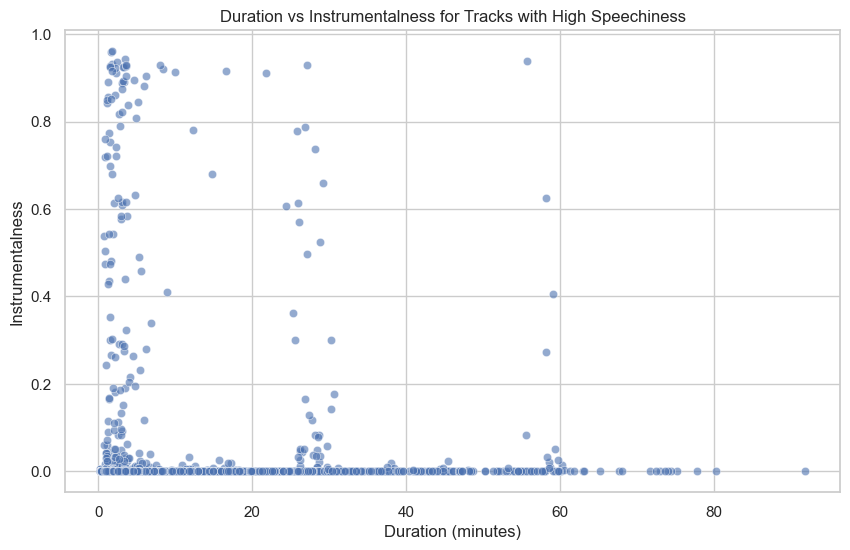

In [17]:
df_filtered_speechiness = df_processed_tracks[df_processed_tracks['speechiness'] > 0.5] # podcast, interview, storybook
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered_speechiness, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with High Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()


We see that for the subset with speechiness above 0.6 the majority of the tracks have low instrumentalness and rather longer duration. This is a clear sign for podcasts. Even shorter tracks with low instrumentalness are presumably not music due to the combination of high speechiness and low instruemntalness.

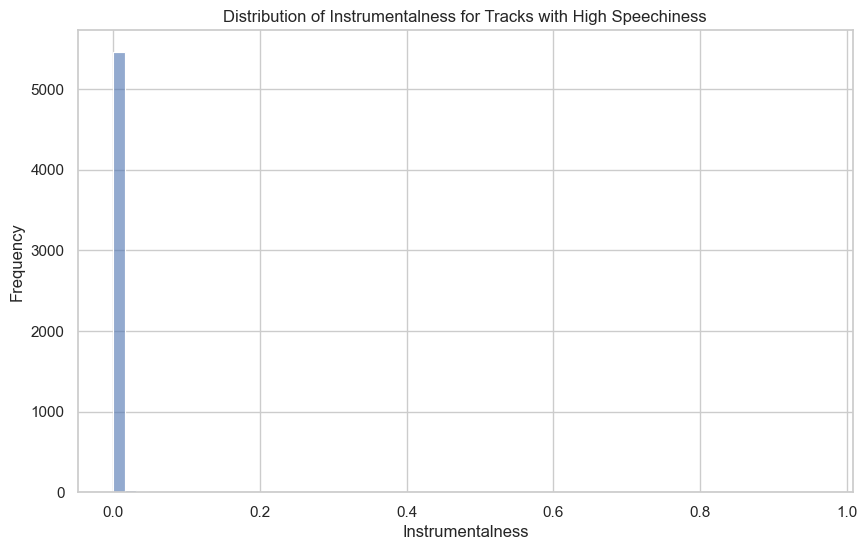

In [18]:
#create a histogram of instrumentalness for tracks that have speechiness above 0.6
df_filtered = df_processed_tracks[df_processed_tracks['speechiness'] > 0.6]
plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='instrumentalness', bins=60, alpha=0.6)
plt.title('Distribution of Instrumentalness for Tracks with High Speechiness')
plt.xlabel('Instrumentalness')
plt.ylabel('Frequency')
plt.show()


In [19]:
num_tracks = len(df_filtered)
num_instrumental = (df_filtered['instrumentalness'] > 0.1).sum()
percentage_instrumental = (num_instrumental / num_tracks) * 100
print(f"Total tracks with speechiness > 0.6: {num_tracks}")
print(f"Tracks with instrumentalness > 0.1: {num_instrumental}")
print(f"Percentage instrumental: {percentage_instrumental:.2f}%")

Total tracks with speechiness > 0.6: 5593
Tracks with instrumentalness > 0.1: 80
Percentage instrumental: 1.43%


Verdict is to exclude all tracks with speechiness above 0.6. We risk the exclusion of 80 potential music tracks. However the cost of leaving a podcast in is greater, than the loss of excluding music so we decided to set the cutoff thresholds accordingly.

We move on to lower speechiness tracks. namely the next bin is speechiness between 0.5 and 0.6.

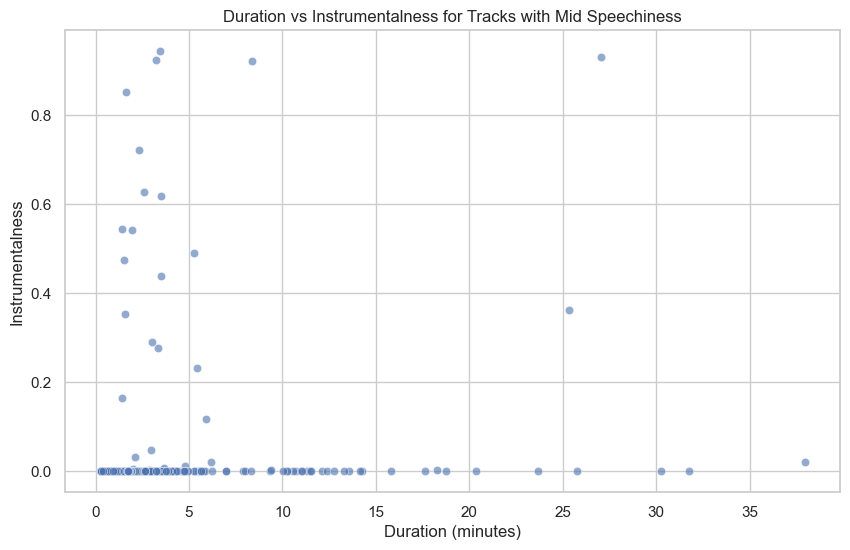

In [20]:
df_filtered = df_processed_tracks[(df_processed_tracks['speechiness'] <= 0.6) & (df_processed_tracks['speechiness'] > 0.55)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with Mid Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()


Here due to the lower threshold of speechiness we will also require low instrumentalness (under 0.1) for cutoff.

In [21]:
df_filtered_instrumental = df_processed_tracks[(df_processed_tracks['speechiness'] < 0.1)]

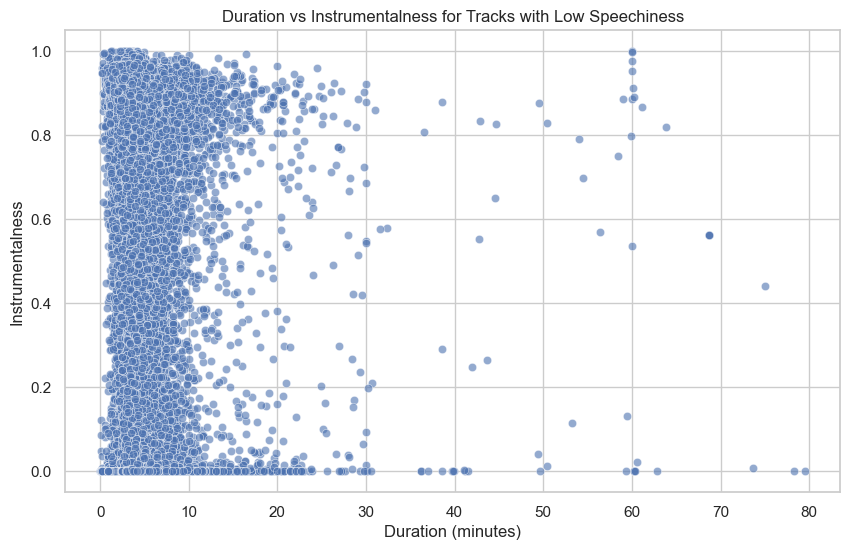

In [22]:
df_filtered = df_processed_tracks[(df_processed_tracks['speechiness'] <= 0.5)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with Low Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()


For speechiness under 0.5, we clearly see the instrumentalness shoots up substantially compared to the previous two graphs. We eliminated with these rules a total of 6197 tracks.


The dataset was again checked and it was noticed that we still had some non songs in the dataset. These playlists was removed adhoc.

In [23]:
# remove playlist Animal Stories and Mythologies
stories_mask = (
    df_processed_tracks["playlist"]
    .fillna("")
    .str.lower()
    .str.strip()
    .isin(["animal stories", "mythologies","learn chinese","learn arabic","learn swedish","learn italian","sci-fi radio dramas","learn french","learn russian","showstopper: season one"])
)

df_filtered_playlist = df_processed_tracks.loc[stories_mask]


Remove the track that are episodes or lessons.

In [24]:
episode_lesson_mask = df_processed_tracks["track_name"].fillna("").str.contains(
    r"\b(episode|lesson)\s*\d+\b",
    case=False,
    regex=True
)

df_filtered_episodes = df_processed_tracks.loc[episode_lesson_mask]

/var/folders/pv/82nsp5sd4rndw85p2vktkjs80000gn/T/ipykernel_13283/1286886727.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  episode_lesson_mask = df_processed_tracks["track_name"].fillna("").str.contains(


### Conclusion
From the perspective of the project the exclusion of a few music tracks is less of an issue, compared to leaving in some non-music tracks. With that being said we will apply the following exclusion logic for non-music tracks.
Exclude all tracks with:
- speechiness above 0.5
- duration above 10 minutes (also full concert recordings and such)
- speechiness between 0.5 and 0.6 and instrumentalness under 0.1

Disclaimer: values of 0 in instrumentalness likely denote missing values rather than no instrumentalness.


In [25]:
print(f"Original processed tracks: {len(df_processed_tracks):,}")


Original processed tracks: 101,939


We also mark the roughly 400 tracks that are less than a minute long. During the analysis we came across some sound samples such as rain or scissors cutting paaper.

Mark all tracks not relevant as "podcasts".

In [26]:
# Create podcast removal mask
podcast_mask = ~(
    (df_processed_tracks['speechiness'] <= 0.5) &
    (df_processed_tracks['duration_minutes'] <= 10) &
    ~(
        (df_processed_tracks['speechiness'] > 0.5) & 
        (df_processed_tracks['speechiness'] <= 0.6) & 
        (df_processed_tracks['instrumentalness'] < 0.1)
    ) &
    ~df_processed_tracks["track_id"].isin(df_filtered_episodes["track_id"]) &
    ~df_processed_tracks["track_id"].isin(df_filtered_playlist["track_id"])
)

# Also mark tracks shorter than 1 minute as podcasts/non-music
short_track_mask = df_processed_tracks['duration_minutes'] < 1
podcast_mask = podcast_mask | short_track_mask

# Mark removed rows as podcasts
df_processed_tracks["is_podcast"] = "no"
df_processed_tracks.loc[podcast_mask, "is_podcast"] = "yes"

df_tracks = df_processed_tracks.copy()

print(df_tracks["is_podcast"].value_counts())


is_podcast
no     94012
yes     7927
Name: count, dtype: int64


In [27]:
# Build Analytics Tracks Table (denormalized with full context)
print("Building analytics tracks table with full joins...")

# Create a copy to avoid side effects
df_base = df_tracks#.copy()

# CLEAN: artists_id is often "['ID']", extract the first one safely
is_list_format = df_base["artists_id"].str.contains(r"\[", na=False)
if is_list_format.any():
    df_base.loc[is_list_format, "artists_id"] = df_base.loc[is_list_format, "artists_id"].str.extract(r"'(.*?)'")[0]

# FILTER: Only keep tracks that reference valid artists AND valid albums
valid_album_ids = df_albums["album_id"].unique()

df_tracks_filtered = df_base[
    (df_base["artists_id"].isin(valid_artist_ids)) & 
    (df_base["album_id"].isin(valid_album_ids))
]#.copy()

print(f"Filtered tracks: {len(df_tracks_filtered):,}/{len(df_base):,} have valid references")

# Join tracks with features
df_tracks_final = df_tracks_filtered.merge(df_processed_features, on="track_id", how="left")

Building analytics tracks table with full joins...
Filtered tracks: 101,144/101,939 have valid references


In [28]:
# Join with artists
artists_cols = df_artists.copy()
artists_cols = artists_cols.rename(
    columns={c: f"artist_{c}" for c in df_artists.columns}
)
df_tracks_final = df_tracks_final.merge(
    artists_cols,
    left_on="artists_id",
    right_on="artist_artist_id",
    how="left",
)

# Join with albums
albums_cols = df_albums.copy()
albums_cols = albums_cols.rename(
    columns={c: f"album_{c}" for c in df_albums.columns}
)
df_tracks_final = df_tracks_final.merge(
    albums_cols,
    left_on="album_id",
    right_on="album_album_id",
    how="left",
)

# Select final columns
final_cols = [
    "track_id", "track_name", "popularity", "duration_ms",
    "preview_url", "uri", "album_id", "album_album_name", "album_album_type",
    "album_release_date", "artists_id", "artist_artist_name",
    "artist_artist_popularity", "artist_followers", "artist_genres","is_podcast",
    # Genre columns from artist (primary/secondary + broad mappings)
    "artist_primary_genre", "artist_secondary_genre", "artist_primary_genre_broad", "artist_secondary_genre_broad",
    # Audio features
    "acousticness", "danceability", "energy", "instrumentalness", "key",
    "liveness", "loudness", "mode", "speechiness", "tempo",
    "time_signature", "valence",
    # Lyrics features
    "mean_syllables_word", "mean_words_sentence", "n_sentences", "n_words",
    "sentence_similarity", "vocabulary_wealth",
]

df_tracks_final = df_tracks_final[[c for c in final_cols if c in df_tracks_final.columns]]#.copy()

# Rename for clarity
df_tracks_final = df_tracks_final.rename(
    columns={
        "popularity": "track_popularity",
        "album_album_name": "album_name",
        "album_album_type": "album_type",
        "album_release_date": "release_date",
        "artist_artist_name": "artist_name",
        "artist_artist_popularity": "artist_popularity",
        "artist_genres": "genres",
    }
)

In [29]:
# Ensure correct types
df_tracks_final["track_popularity"] = df_tracks_final["track_popularity"].fillna(0).astype("int64")
df_tracks_final["duration_ms"] = df_tracks_final["duration_ms"].fillna(0).astype("int64")
df_tracks_final["artist_popularity"] = df_tracks_final["artist_popularity"].fillna(0).astype("int64")
df_tracks_final["artist_followers"] = df_tracks_final["artist_followers"].fillna(0).astype("int64")

# Audio feature integers
for col in ["key", "mode", "time_signature"]:
    if col in df_tracks_final.columns:
        df_tracks_final[col] = df_tracks_final[col].fillna(0).astype("int64")

print(f"Analytics tracks: {len(df_tracks_final):,} rows, {len(df_tracks_final.columns):,} columns")


Analytics tracks: 101,144 rows, 38 columns


In [30]:
# Finalize Analytics Track Features
print("Finalizing analytics track features...")

# Merge audio features with lyrics features
if lyrics_cols:
    df_lyrics = df_processed_features[["track_id"] + lyrics_cols].copy()
    df_lyrics = df_lyrics.drop_duplicates(subset=["track_id"])
    df_features_final = df_track_features_audio.merge(df_lyrics, on="track_id", how="left")
else:
    df_features_final = df_track_features_audio

df_features_final = df_features_final.fillna(0)

# FILTER: Only keep features for valid tracks (Foreign Key constraint)
valid_track_ids = df_tracks_final["track_id"].unique()
df_features_final = df_features_final[df_features_final["track_id"].isin(valid_track_ids)].copy()

# Ensure correct types for audio feature integers
for col in ["key", "mode", "time_signature"]:
    if col in df_features_final.columns:
        df_features_final[col] = df_features_final[col].fillna(0).astype("int64")

print(f"Analytics features: {len(df_features_final):,} rows, {len(df_features_final.columns):,} columns")


Finalizing analytics track features...
Analytics features: 101,144 rows, 19 columns


## Further Analysis for Podcasts and Genres

In [31]:
df_tracks = df_tracks_final.copy()

Check to see the distribution of tracks marked as "podcast" and the ones that should be normal songs.

In [32]:
podcast_summary = pd.DataFrame({
    "count": df_tracks["is_podcast"].value_counts(),
    "percentage": df_tracks["is_podcast"].value_counts(normalize=True).mul(100).round(2)
})

podcast_summary

,count,percentage
is_podcast,,
no,93408,92.35
yes,7736,7.65


Check to see how my features split my data podcast vs. normal tracks.

In [33]:
audio_features = [
    "duration_ms",
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "time_signature",
    "valence"
]

artist_features = [
    "artist_popularity",
    "artist_followers"
]

text_features = [
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]

categorical_features = [
    "album_type",
    "artist_primary_genre_broad",
    "artist_secondary_genre_broad"
]

numeric_features = audio_features + artist_features + text_features
summary_mean = df_tracks.groupby("is_podcast")[numeric_features].mean().T
summary_median = df_tracks.groupby("is_podcast")[numeric_features].median().T

podcast_comparison = summary_mean.join(
    summary_median,
    lsuffix="_mean",
    rsuffix="_median"
)

podcast_comparison

is_podcast,no_mean,yes_mean,no_median,yes_median
duration_ms,230120.834607,446604.947518,217116.000000,200833.500000
acousticness,0.326347,0.646381,0.200000,0.704000
danceability,0.586434,0.581967,0.607000,0.631000
energy,0.605685,0.366344,0.647000,0.314000
instrumentalness,0.153467,0.089342,0.000063,0.000000
liveness,0.187629,0.316272,0.121000,0.220000
loudness,-8.817602,-16.890856,-7.292000,-16.955000
speechiness,0.081633,0.686821,0.048200,0.878000
tempo,119.698096,102.625672,119.946000,98.948500
time_signature,3.906678,3.510341,4.000000,4.000000


The summary statistics show clear differences between podcast and non-podcast tracks. 
Podcast-labelled tracks are much more speech-heavy, with a median speechiness of 0.888 compared with 0.048 for non-podcasts. They are also quieter, less energetic, and more acoustic. 

Although podcast tracks have a higher mean duration, their median duration is similar to non-podcast tracks, suggesting that the podcast group contains a mixture of long recordings and shorter segmented spoken-content tracks (which is to be expected since we also removed some tracks ad-hoc). 
Text-based features also support the separation: podcast tracks have substantially more words and higher vocabulary wealth. 

Overall, the created podcast label appears plausible and captures tracks with strong spoken-audio characteristics.

## One-Class SVM

One-Class SVM was used to learn the feature pattern of tracks labelled as podcasts. The trained model was then applied to tracks labelled as non-podcasts to identify tracks that showed similar characteristics to the podcast group. These tracks were treated as possible missed podcasts or non-music tracks and inspected further.

In [34]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import OneClassSVM

# Prepare features
features = numeric_features + categorical_features

numeric_features = [col for col in numeric_features if col in df_tracks.columns]
categorical_features = [col for col in categorical_features if col in df_tracks.columns]
features = numeric_features + categorical_features

df_yes = df_tracks[df_tracks["is_podcast"] == "yes"].copy()
df_no = df_tracks[df_tracks["is_podcast"] == "no"].copy()

print("Known podcasts:", df_yes.shape[0])
print("Marked non-podcasts:", df_no.shape[0])

# Preprocess features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

X_yes = preprocessor.fit_transform(df_yes[features])
X_no = preprocessor.transform(df_no[features])

# Train One-Class SVM only on known podcasts
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.6
)

ocsvm.fit(X_yes)

# Prediction:
#  1 = similar to podcast group
# -1 = not similar to podcast group
df_no["ocsvm_prediction"] = ocsvm.predict(X_no)

# Higher score = more podcast-like
df_no["ocsvm_score"] = ocsvm.decision_function(X_no)

# Extract possible missed podcasts
possible_missed_podcasts_ocsvm = df_no[
    df_no["ocsvm_prediction"] == 1
].sort_values("ocsvm_score", ascending=False)

candidate_cols = [
    "track_id",
    "track_name",
    "artist_name",
    "album_name",
    "genres",
    "artist_primary_genre",
    "artist_primary_genre_broad",
    "artist_secondary_genre_broad",
    "is_podcast",
    "ocsvm_prediction",
    "ocsvm_score",
    "duration_ms",
    "speechiness",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "n_words",
    "vocabulary_wealth",
    "track_popularity",
    "artist_popularity",
    "artist_followers"
]

candidate_cols = [col for col in candidate_cols if col in possible_missed_podcasts_ocsvm.columns]

print("Possible missed podcasts using One-Class SVM:", possible_missed_podcasts_ocsvm.shape[0])



Known podcasts: 7736
Marked non-podcasts: 93408
Possible missed podcasts using One-Class SVM: 2075


Different values of the One-Class SVM parameter nu were tested to control how many non-podcast tracks were flagged as podcast-like. Lower nu values were too broad and classified a large share of the non-podcast group as similar to podcasts. For example, nu=0.05 flagged 82.85% of the non-podcast tracks, which was not useful for manual inspection. As nu increased, the model became more selective. The value nu=0.60 flagged only 2075 tracks, representing 2.2% of the non-podcast group. Therefore, nu=0.60 was selected because it produced a small and manageable set of high-priority candidates for further manual review.

In [35]:
possible_missed_podcasts_ocsvm[candidate_cols].head(5)

,track_id,track_name,artist_name,album_name,genres,artist_primary_genre,artist_primary_genre_broad,artist_secondary_genre_broad,is_podcast,ocsvm_prediction,...,speechiness,energy,loudness,acousticness,instrumentalness,n_words,vocabulary_wealth,track_popularity,artist_popularity,artist_followers
15308,0cqetEMWwpwK2ssYu5iLu5,Barley,Birds of Chicago,Real Midnight,[],,,,no,1,...,0.489,0.275,-9.651,0.650,0.0,268.0,0.64,36,31,6554
35435,6iqoDOuXWIIh1eg01gWDba,A Voz,Kivitz,Em Nome do Vento,['rap cristao'],rap cristao,hip hop,,no,1,...,0.406,0.533,-12.489,0.539,0.0,587.0,0.74,29,43,9239
34708,0K9n8TBThz4xNAkF1eIlB6,Sweet Transvestite,Tim Curry,The Rocky Horror Picture Show - Original Sound...,['hollywood'],hollywood,house,,no,1,...,0.383,0.422,-12.243,0.592,0.0,338.0,0.69,56,47,15900
46324,7LIMVYx5Xqfs8zBLwgB7eX,Folge 122: Inferno in der Alptraum-Schlucht. T...,John Sinclair,Folge 122: Inferno in der Alptraum-Schlucht. T...,"['hoerspiel', 'kleine hoerspiel', 'reading']",hoerspiel,house,classical,no,1,...,0.487,0.546,-16.280,0.400,0.0,470.0,0.67,19,58,25097
79449,5NzrPsQUasCgimzBrtFPpu,Introduction to Buddhism,Emma Hignett,Introduction to Buddhism,[],,,,no,1,...,0.409,0.263,-19.637,0.591,0.0,271.0,0.75,8,12,187


### Plausability check
Check to see if the tracks marked as possible podcasts are plausible.

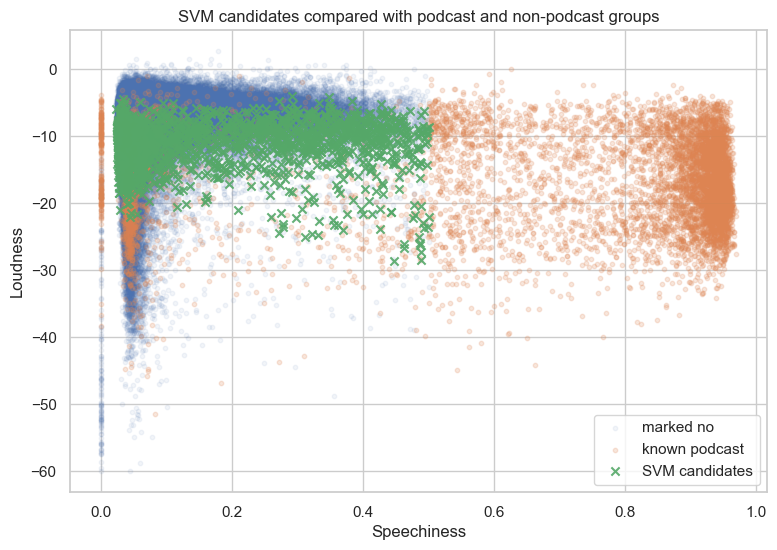

In [36]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_tracks[df_tracks["is_podcast"] == "no"]["speechiness"],
    df_tracks[df_tracks["is_podcast"] == "no"]["loudness"],
    alpha=0.07,
    s=10,
    label="marked no"
)

plt.scatter(
    df_tracks[df_tracks["is_podcast"] == "yes"]["speechiness"],
    df_tracks[df_tracks["is_podcast"] == "yes"]["loudness"],
    alpha=0.20,
    s=10,
    label="known podcast"
)

plt.scatter(
    possible_missed_podcasts_ocsvm["speechiness"],
    possible_missed_podcasts_ocsvm["loudness"],
    alpha=0.9,
    s=35,
    marker="x",
    label="SVM candidates"
)

plt.xlabel("Speechiness")
plt.ylabel("Loudness")
plt.title("SVM candidates compared with podcast and non-podcast groups")
plt.legend()
plt.show()

The plot shows that the SVM candidates are located mainly in the overlap between non-podcast tracks and known podcasts, especially at moderate speechiness and lower loudness. This suggests that the model is identifying borderline tracks that share podcast-like audio characteristics and should be reviewed manually before relabelling.

The possible missed tracks are further inspected ad-hoc.

In [37]:
import re

spoken_keyword_list = [
    r"\bintroduction to\b",
    r"\bbuddhism\b",
    r"\bfolge\s*\d+",
    r"\bteil\s*\d+",
    r"\bkapitel\s*\d+",
    r"\bchapter\s*\d+",
    r"\bpart\s*\d+",
    r"\blesson\s*\d+",
    r"hörspiel",
    r"hoerspiel",
    r"audiobook",
    r"audio book",
    r"self help audio books",
    r"bedtime stories",
    r"fairy tales",
    r"slam poetry",
    r"poetry collection",
    r"narrated by",
    r"reading her poetry",
    r"read in french",
    r"vocabulearn",
    r"learn in your car",
    r"present tense patterns",
    r"\bar verbs\b",
    r"\ber verbs\b",
    r"\bir verbs\b",
    r"john sinclair",
    r"fünf freunde",
    r"funf freunde",
    r"die drei !!!",
    r"die drei \?\?\?",
    r"hanni und nanni",
    r"tkkg",
    r"teufelskicker",
    r"der kleine prinz",
    r"shel silverstein",
    r"jack kerouac",
    r"jean vilar",
    r"paul a\. mankin",
    r"sylvia plath",
    r"dylan thomas",
    r"langston hughes",
    r"william shakespeare",
    r"shakespeare",
    r"john keats",
    r"malcolm x",
    r"tabaluga",
    r"käpt'n sharky",
    r"kaept'n sharky",
    r"petit ours brun",
    r"emily dickinson",
    r"english romantic poetry",
    r"selected readings",
    r"bhagavad gita",
    r"speeches & poems",
    r"revolutionary speeches",
    r"john s\. martin",
    r"samuel b\. charters",
    r"christopher isherwood",
    r"michael macliammoir",
    r"the letters of emily dickinson",
    r"selected readings from the bhagavad",
    r"minuto com deus",
    r"devocionais",
    r"judith anderson",
    r"a child's garden of verses",
    r"lewis carroll",
    r"nonsense verse",
    r"john s\. martin",
    r"english romantic poetry",
    r"sir john gielgud",
    r"william shakespeare's hamlet",
    r"pablo neruda",
    r"samuel b\. charters",
    r"emily dickinson",
    r"christopher isherwood",
    r"selected readings from the bhagavad",
    r"bhagavad gita",
    r"michael macliammoir",
    r"revolutionary speeches",
    r"speeches & poems",
    r"benjamin blümchen",
    r"benjamin bluemchen",
    r"käpt'n sharky",
    r"kaept'n sharky",
    r"petit ours brun",
    r"bamse",
    r"pastor edvaldo oliveira",
    r"minuto com deus",
    r"devocionais",
    r"margaret cho",
    r"garfunkel and oates",
    r"peter sellers",
    r"emi comedy"
]

spoken_keywords = "|".join(spoken_keyword_list)

possible_missed_podcasts_ocsvm = possible_missed_podcasts_ocsvm.copy()

text_for_check = (
    possible_missed_podcasts_ocsvm["track_name"].fillna("").str.lower()
    + " "
    + possible_missed_podcasts_ocsvm["artist_name"].fillna("").str.lower()
    + " "
    + possible_missed_podcasts_ocsvm["album_name"].fillna("").str.lower()
    + " "
    + possible_missed_podcasts_ocsvm["genres"].astype(str).fillna("").str.lower()
)

possible_missed_podcasts_ocsvm["review_category"] = "needs_manual_review"

possible_missed_podcasts_ocsvm.loc[
    text_for_check.str.contains(spoken_keywords, regex=True, na=False),
    "review_category"
] = "very_likely_non_music"

possible_missed_podcasts_ocsvm["review_category"].value_counts()

review_category
needs_manual_review      1952
very_likely_non_music     123
Name: count, dtype: int64

Check which words matched.

In [38]:
matches = []

for keyword in spoken_keyword_list:
    count = text_for_check.str.contains(keyword, regex=True, na=False).sum()
    if count > 0:
        matches.append({"keyword": keyword, "matched_rows": count})

keyword_match_summary = (
    pd.DataFrame(matches)
    .sort_values("matched_rows", ascending=False)
)

keyword_match_summary

,keyword,matched_rows
8,hoerspiel,62
3,\bteil\s*\d+,60
23,die drei !!!,22
2,\bfolge\s*\d+,10
4,\bkapitel\s*\d+,10
...,...,...
44,samuel b\. charters,1
46,the letters of emily dickinson,1
48,minuto com deus,1
49,devocionais,1


Mark the 123 found tracks as "podcast"  in our dataset.

In [39]:
podcast_summary = pd.DataFrame({
    "count_before_SVM": df_tracks["is_podcast"].value_counts(),
    "percentage_before_SVM": df_tracks["is_podcast"].value_counts(normalize=True).mul(100).round(2)
})

podcast_summary

,count_before_SVM,percentage_before_SVM
is_podcast,,
no,93408,92.35
yes,7736,7.65


In [40]:
# Get track_ids that were classified as very likely non-music
very_likely_non_music_ids = possible_missed_podcasts_ocsvm.loc[
    possible_missed_podcasts_ocsvm["review_category"] == "very_likely_non_music",
    "track_id"
]

# Mark them as podcasts in df_tracks
df_tracks.loc[
    df_tracks["track_id"].isin(very_likely_non_music_ids),
    "is_podcast"
] = "yes"

podcast_summary = pd.DataFrame({
    "count_after_SVM": df_tracks["is_podcast"].value_counts(),
    "percentage_after_SVM": df_tracks["is_podcast"].value_counts(normalize=True).mul(100).round(2)
})

podcast_summary

,count_after_SVM,percentage_after_SVM
is_podcast,,
no,93285,92.23
yes,7859,7.77


## Genre clustering

In this step we imputed the genre for tracks missing it, based on the clustering of different broad genres by features.

In [41]:
# Work only with music tracks
df_music = df_tracks[df_tracks["is_podcast"] == "no"].copy()

target_genre_col = "artist_primary_genre_broad"

# Define missing broad genre
missing_genre_mask = (
    df_music[target_genre_col].isna()
    | (df_music[target_genre_col].astype(str).str.strip() == "")
)

df_known_genre = df_music[~missing_genre_mask].copy()
df_missing_genre = df_music[missing_genre_mask].copy()

print("Known broad genre tracks:", df_known_genre.shape[0])
print("Missing broad genre tracks:", df_missing_genre.shape[0])

genre_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

genre_features = [col for col in genre_features if col in df_tracks.columns]

genre_profiles = (
    df_known_genre
    .groupby(target_genre_col)[genre_features]
    .mean()
    .dropna()
)

genre_profiles

Known broad genre tracks: 76745
Missing broad genre tracks: 16540


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
artist_primary_genre_broad,,,,,,,,,
blues,0.403482,0.584010,0.592961,0.105705,0.193770,-8.968175,0.067263,119.036993,0.575263
classical,0.525854,0.500636,0.464214,0.272405,0.178447,-13.053934,0.060396,116.084872,0.427880
electronic,0.386193,0.578703,0.552925,0.383091,0.174413,-11.295080,0.071592,117.595714,0.389185
folk,0.462537,0.548873,0.533898,0.087743,0.184860,-9.329345,0.055196,120.114911,0.511072
hip hop,0.249404,0.669294,0.651624,0.125247,0.180396,-7.669392,0.144870,119.185178,0.540147
house,0.157723,0.667281,0.722343,0.266494,0.192543,-7.228745,0.084000,122.694491,0.461130
indie,0.348075,0.546299,0.580345,0.126033,0.175447,-8.653114,0.057002,120.167163,0.455018
jazz,0.401273,0.617921,0.571484,0.238476,0.180981,-9.040404,0.073519,119.952192,0.574527
metal,0.162805,0.502351,0.787936,0.112032,0.232220,-6.366192,0.082904,125.483731,0.455771


The genre profiles show that broad genres differ in their average audio characteristics. Genres such as house, hip hop, and metal are generally more energetic and louder, while classical is more acoustic, quieter, and more instrumental. Hip hop has the highest speechiness, and house has one of the highest danceability values. These patterns support using audio-feature similarity to estimate missing broad genre labels.

To extract the information regarding genres, we used the distances from the nearest neighbours. Genres were extracted only for tracks that were missing one.

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

df_missing_for_match = df_missing_genre.dropna(subset=genre_features).copy()

scaler = StandardScaler()

X_genres = scaler.fit_transform(genre_profiles[genre_features])
X_missing = scaler.transform(df_missing_for_match[genre_features])

nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(X_genres)

distances, indices = nn.kneighbors(X_missing)

df_missing_for_match["predicted_artist_primary_genre_broad"] = genre_profiles.index[indices.flatten()]
df_missing_for_match["genre_match_distance"] = distances.flatten()
df_missing_for_match["genre_match_score"] = 1 / (1 + df_missing_for_match["genre_match_distance"])

df_missing_for_match[
    [
        "track_name",
        "artist_name",
        target_genre_col,
        "predicted_artist_primary_genre_broad",
        "genre_match_score",
        "genre_match_distance"
    ]
].sort_values("genre_match_score", ascending=False).head(10)

,track_name,artist_name,artist_primary_genre_broad,predicted_artist_primary_genre_broad,genre_match_score,genre_match_distance
25642,Funky Feelings,LIVI,,blues,0.331474,2.016827
82458,Deixa Eu Te Encontrar,Julia Sicone,,folk,0.287297,2.480715
78840,Poncho Konos,T3R Elemento,,pop,0.278739,2.587581
84786,Pra Tua Glória,Novidade de Vida Music,,metal,0.278665,2.588533
92095,Un Antes y un Después,Marcelo Ezquiaga,,pop,0.277014,2.609928
10031,"Mä annan sut pois (Tähdet, tähdet kausi 5)",Jussi Rainio,,world,0.276168,2.620984
32836,הבלדה על חדווה ושלומיק,Miri Aloni,,metal,0.268386,2.725970
60,ADORO BOLOS,Conan Osíris,,world,0.265383,2.768142
27154,Changed My Ways,Murray A. Lightburn,,blues,0.262909,2.803601
23825,Feel Your Love,KRYGA,,pop,0.262708,2.806510


In [43]:
df_missing_for_match["predicted_artist_primary_genre_broad"].value_counts()

predicted_artist_primary_genre_broad
r&b           2765
metal         2510
classical     2410
hip hop       1642
house         1141
world         1115
electronic    1057
pop            998
jazz           789
indie          737
blues          526
rock           499
folk           351
Name: count, dtype: int64

In [44]:
# Backup original column first
df_tracks["artist_primary_genre_broad_original"] = df_tracks["artist_primary_genre_broad"]

# Map predicted genres by track_id
prediction_map = df_missing_for_match.set_index("track_id")[
    "predicted_artist_primary_genre_broad"
]

# Define rows where broad genre is missing
missing_mask = (
    df_tracks["artist_primary_genre_broad"].isna()
    | (df_tracks["artist_primary_genre_broad"].astype(str).str.strip() == "")
)

# Override only missing values
df_tracks.loc[
    missing_mask & df_tracks["track_id"].isin(prediction_map.index),
    "artist_primary_genre_broad"
] = df_tracks.loc[
    missing_mask & df_tracks["track_id"].isin(prediction_map.index),
    "track_id"
].map(prediction_map)

# Mark imputed rows
df_tracks["genre_broad_was_imputed"] = (
    missing_mask & df_tracks["track_id"].isin(prediction_map.index)
)

# Check result
df_tracks["genre_broad_was_imputed"].value_counts()

genre_broad_was_imputed
False    84604
True     16540
Name: count, dtype: int64

In [45]:
df_tracks["artist_primary_genre_broad"].value_counts()

artist_primary_genre_broad
pop           17782
hip hop       13969
classical     11207
rock           9891
indie          9432
house          8174
metal          5872
r&b            5060
world          4740
electronic     3866
jazz           3534
blues          3157
folk           2286
               2174
Name: count, dtype: int64

In [46]:
# show me teh is_podcast value counts in df_tracks
df_music["is_podcast"].value_counts()

is_podcast
no    93285
Name: count, dtype: int64

## Building Final Analytics Tables with Joins

Combining all cleaned and preprocessed data with full denormalization and context.


In [47]:
# Save All Analytics Tables to Parquet
print("\n" + "="*60)
print("SAVING ANALYTICS TABLES")
print("="*60 + "\n")

# Ensure analytics directory exists
config.DATA_ANALYTICS.mkdir(parents=True, exist_ok=True)

# Save each table
df_artists.to_parquet(config.ANALYTICS_ARTISTS, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_artists):,} artists to {config.ANALYTICS_ARTISTS}")

df_albums.to_parquet(config.ANALYTICS_ALBUMS, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_albums):,} albums to {config.ANALYTICS_ALBUMS}")

df_tracks.to_parquet(config.ANALYTICS_TRACKS, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_tracks):,} tracks to {config.ANALYTICS_TRACKS}")

df_genres.to_parquet(config.ANALYTICS_GENRES, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_genres):,} genre mappings to {config.ANALYTICS_GENRES}")

df_features_final.to_parquet(config.ANALYTICS_TRACK_FEATURES, engine="pyarrow", index=False)
print(f"✓ Saved {len(df_features_final):,} feature records to {config.ANALYTICS_TRACK_FEATURES}")

print("\nAll analytics tables saved successfully!")



SAVING ANALYTICS TABLES

✓ Saved 56,129 artists to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/analytics/analytics_artists.parquet
✓ Saved 74,991 albums to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/analytics/analytics_albums.parquet
✓ Saved 101,144 tracks to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/analytics/analytics_tracks.parquet
✓ Saved 87,202 genre mappings to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/analytics/analytics_genres.parquet
✓ Saved 101,144 feature records to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/analytics/analytics_track_features.parquet

All analytics tables saved successfully!
